In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q --no-cache-dir google-search-results
import importlib, sys, pkgutil, subprocess, json

  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Display the first 10 lines of the CSV file to inspect its structure
print("\n=== CSV File Head ==")
!head -n 10 "/content/london_photos2 (2).csv"
print("=====================\n")

# 读取你的 CSV（改成你的文件名）
# 如果遇到 ParserError，可能需要调整 `sep` 参数，例如：sep=';' 或 sep='\t'
# 也可以尝试 on_bad_lines='skip' 或 engine='python' 来处理错误行
df = pd.read_csv("/content/london_photos2 (2).csv", sep='\t') # 显式指定制表符分隔符

# 初始化 VADER
analyzer = SentimentIntensityAnalyzer()

# 如果你要打印例子（可选）
examples = [
    "I love this! It's amazing and makes me so happy.",
    "This is the worst. I hate it and I'm disappointed.",
    "I'm not sure how I feel about this...",
    "LOL that was hilarious! :D",
    "The product is okay, but not great."
]

print("\n=== 示例句子评分 ==")
for text in examples:
    scores = analyzer.polarity_scores(text)
    print(text)
    print("  ->", scores)

# 对标题进行情绪打分
print("\n=== TikTok 标题情绪评分 ==")
for title in df["title"].fillna(""):
    scores = analyzer.polarity_scores(title)
    print(title)
    print("  ->", scores)


=== CSV File Head ==
	id	server	secret	title	tags	views	description	date_taken	latitude	longitude	url_s	owner_name	owner	media
0	54605062472	65535	da2bc48b7f	Tintoretto Trafugamento del corpo di San Marco		186	Venezia Gallerie dell'Accademia	2016-08-13 16:40:36	45.431120	12.328140	https://live.staticflickr.com/65535/54605062472_da2bc48b7f_m.jpg	Giovanni Rivetti	82911286@N03	photo
1	54605061787	65535	b1a00bc615	Cima da Conegliano Pietà		191	Venezia Gallerie dell'Accademia	2016-08-13 16:35:09	45.431120	12.328140	https://live.staticflickr.com/65535/54605061787_b1a00bc615_m.jpg	Giovanni Rivetti	82911286@N03	photo
2	54608222500	65535	6a8a6a3353	20241117_212242		2		2024-11-17 21:22:43	45.434369	12.338469	https://live.staticflickr.com/65535/54608222500_6a8a6a3353_m.jpg	Colorgrinder	14218314@N07	photo
3	54607043322	65535	734c35ca57	20241117_212457		2		2024-11-17 21:24:59	45.434352	12.338436	https://live.staticflickr.com/65535/54607043322_734c35ca57_m.jpg	Colorgrinder	14218314@N07	photo
4	5457

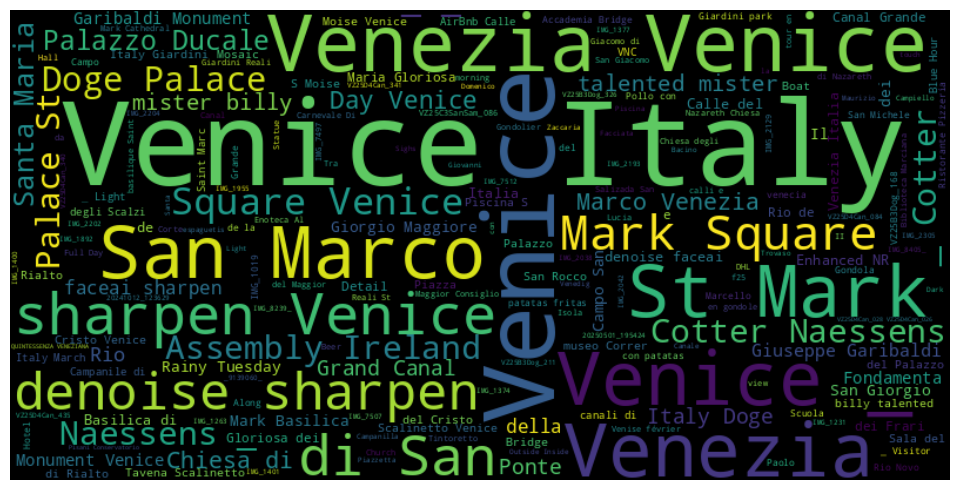

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv("/content/london_photos2 (2).csv", sep='\t')

text = " ".join(df["title"].fillna("").tolist())

wc = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 32490 (\N{CJK UNIFIED IDEOGRAPH-7EEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-468398273.py:48: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from

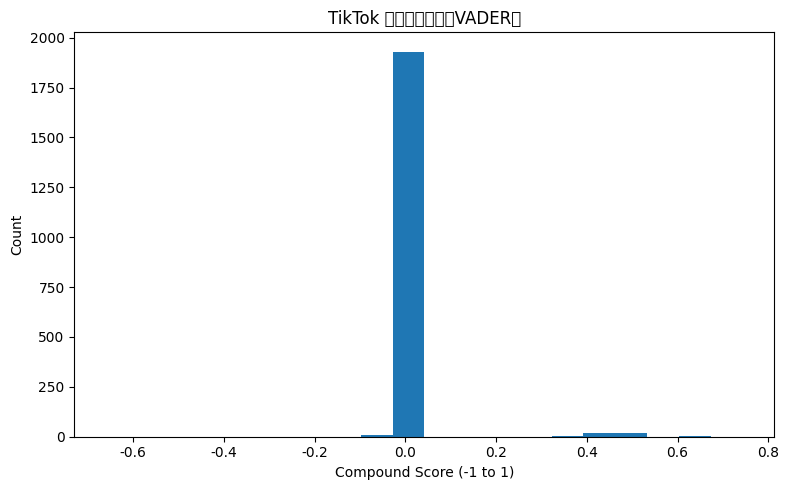

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Install a CJK font for matplotlib (if not already installed)
!pip install -q matplotlib fonttools

# Define font path and name
font_path = '/usr/local/share/fonts/NotoSansCJKsc-Regular.otf'
font_dir = '/usr/local/share/fonts/'
font_name = 'Noto Sans CJK SC'

# Create the directory if it doesn't exist
!mkdir -p "{font_dir}"

# Download a CJK font (e.g., Noto Sans CJK SC) to the specified directory
!wget -q https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTC/NotoSansCJKsc-Regular.otf -O "{font_path}"

# Remove Matplotlib's font cache to force a rebuild
!rm -rf ~/.cache/matplotlib

# Matplotlib will rebuild its cache implicitly when it needs to find fonts
# Or, we can trigger a scan for system fonts explicitly after cleaning cache
fm.findSystemFonts(fontpaths=None, fontext='ttf')

# Set the font (Matplotlib will find it from the system path after rebuild)
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False # This is for displaying minus signs properly

df = pd.read_csv("/content/london_photos2 (2).csv", sep='\t')

analyzer = SentimentIntensityAnalyzer()

sentiments = []
for title in df["title"].fillna(""):
    score = analyzer.polarity_scores(title)
    sentiments.append(score["compound"])

df["compound"] = sentiments

plt.figure(figsize=(8,5))
plt.hist(df["compound"], bins=20)
plt.title("TikTok 标题情绪分布（VADER）")
plt.xlabel("Compound Score (-1 to 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("df_TikTok.csv")

analyzer = SentimentIntensityAnalyzer()

examples = [
    "I love this! It's amazing and makes me so happy.",
    "This is the worst. I hate it and I'm disappointed.",
    "I'm not sure how I feel about this...",
    "LOL that was hilarious! :D",
    "The product is okay, but not great."
]

print("\n=== 示例句子评分 ===")
for text in examples:
    scores = analyzer.polarity_scores(text)
    print(text)
    print("  ->", scores)

print("\n=== TikTok 标题情绪评分 ===")
for title in df["title"].fillna(""):
    scores = analyzer.polarity_scores(title)
    print(title)
    print("  ->", scores)


=== 示例句子评分 ===
I love this! It's amazing and makes me so happy.
  -> {'neg': 0.0, 'neu': 0.349, 'pos': 0.651, 'compound': 0.9329}
This is the worst. I hate it and I'm disappointed.
  -> {'neg': 0.609, 'neu': 0.391, 'pos': 0.0, 'compound': -0.8979}
I'm not sure how I feel about this...
  -> {'neg': 0.219, 'neu': 0.781, 'pos': 0.0, 'compound': -0.2411}
LOL that was hilarious! :D
  -> {'neg': 0.0, 'neu': 0.159, 'pos': 0.841, 'compound': 0.89}
The product is okay, but not great.
  -> {'neg': 0.408, 'neu': 0.459, 'pos': 0.133, 'compound': -0.6112}

=== TikTok 标题情绪评分 ===
10 Must-Do Activities in Venice, Italy
  -> {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
15 Must-Do’s in Venice for Your Perfect Trip 🛶✨
  -> {'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'compound': 0.7184}
Explore Free Attractions in Venice, Italy
  -> {'neg': 0.0, 'neu': 0.396, 'pos': 0.604, 'compound': 0.7269}
Explore the Unique Charm of Venice, Italy
  -> {'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.4019}
9

/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 32490 (\N{CJK UNIFIED IDEOGRAPH-7EEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1507272434.py:21: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missi

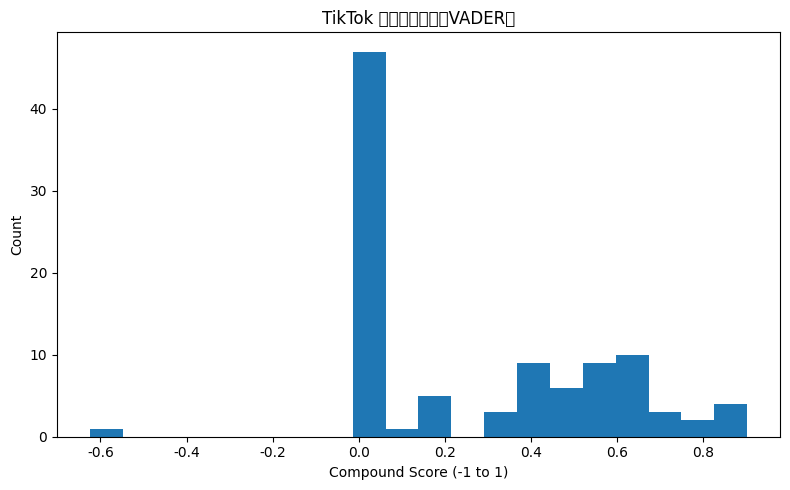

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

df = pd.read_csv("df_TikTok.csv")

analyzer = SentimentIntensityAnalyzer()

sentiments = []
for title in df["title"].fillna(""):
    score = analyzer.polarity_scores(title)
    sentiments.append(score["compound"])

df["compound"] = sentiments

plt.figure(figsize=(8,5))
plt.hist(df["compound"], bins=20)
plt.title("TikTok 标题情绪分布（VADER）")
plt.xlabel("Compound Score (-1 to 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 32490 (\N{CJK UNIFIED IDEOGRAPH-7EEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1681548713.py:21: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missi

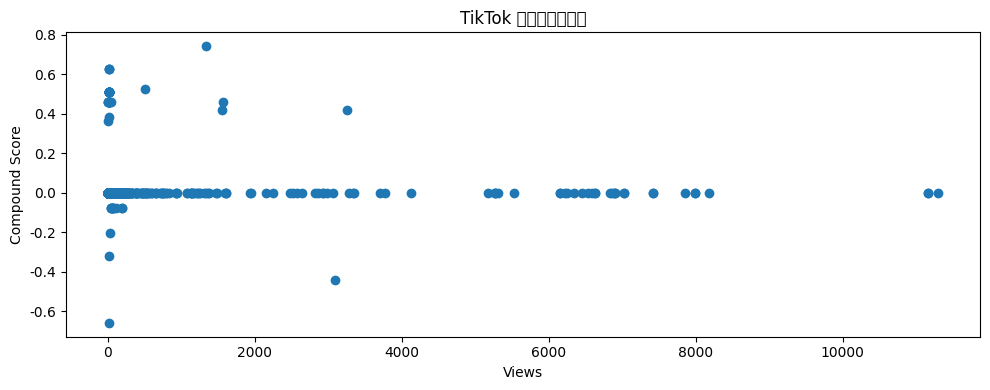

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

df = pd.read_csv("/content/london_photos2 (2).csv", sep='\t') # Added sep='\t' for correct parsing

analyzer = SentimentIntensityAnalyzer()

sentiments = []
for title in df["title"].fillna(""):
    score = analyzer.polarity_scores(title)
    sentiments.append(score["compound"])

df["compound"] = sentiments
plt.figure(figsize=(10,4))
# Changed 'position' to 'views' as 'position' does not exist in the DataFrame
plt.scatter(df["views"], df["compound"])
plt.title("TikTok 标题情绪散点图")
plt.xlabel("Views") # Updated xlabel to reflect 'views'
plt.ylabel("Compound Score")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import folium

df = pd.read_csv("/content/df_TikTok.csv", sep='\t') # Changed to the correct CSV and kept sep for this file

m = folium.Map(location=[df["latitude"].mean(), df["longitude"].mean()], zoom_start=13)

for _, row in df.iterrows():
    # Ensure latitude and longitude are not NaN before creating marker
    if pd.isna(row['latitude']) or pd.isna(row['longitude']):
        continue

    # Check if 'description' column exists before adding to popup
    description_text = f"<b>Description:</b> {row['description']}<br>" if 'description' in row else ''
    popup_text = f"""
    <b>Title:</b> {row['title']}<br>
    {description_text}
    """
    folium.Marker(
        location=[row["latitude"], row["longitude"]], # Using 'latitude' and 'longitude'
        popup=popup_text
    ).add_to(m)

m.save("map_with_titles.html")
m

KeyError: 'latitude'

In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the CSV file that contains geographical data
df = pd.read_csv("/content/df_TikTok.csv", sep='\t')

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# Perform sentiment analysis on the 'title' column and add 'compound' score to df
sentiments = []
for title in df["title"].fillna(""):
    score = analyzer.polarity_scores(title)
    sentiments.append(score["compound"])
df["compound"] = sentiments

# Ensure latitude and longitude columns are numeric and handle missing values
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Clean data: drop rows where 'latitude', 'longitude', or 'compound' are missing
df_clean = df.dropna(subset=['latitude', 'longitude', 'compound'])

# Use 'latitude' and 'longitude' and 'compound' for heatmap
heat_data = df_clean[['latitude', 'longitude', 'compound']].values.tolist()

# Black and white base map
m = folium.Map(
    location=[df_clean['latitude'].mean(), df_clean['longitude'].mean()],  # Center map on the mean coordinates
    zoom_start=13,
    tiles="CartoDB Positron"  # Black and white minimalist map
)

# Add heatmap layer
HeatMap(
    heat_data,
    radius=18,
    blur=15,
    min_opacity=0.4,
).add_to(m)

m.save("sentiment_heatmap_bw.html")
m

KeyError: 'title'

In [ ]:
import folium
import pandas as pd
from folium import plugins
import branca.colormap as cm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the CSV file that contains geographical data
df = pd.read_csv("/content/london_photos2 (2).csv", sep='\t')

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# Perform sentiment analysis on the 'title' column and add 'compound' score to df
sentiments = []
for title in df["title"].fillna(""):
    score = analyzer.polarity_scores(title)
    sentiments.append(score["compound"])
df["compound"] = sentiments

# Ensure latitude and longitude columns are numeric and handle missing values
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Clean data: drop rows where 'latitude', 'longitude', or 'compound' are missing
df_clean = df.dropna(subset=['latitude', 'longitude', 'compound'])

colormap = cm.LinearColormap(
    colors=["#0000FF", "#808080", "#FF0000"], # Changed to hex codes: blue, gray, red
    vmin=-1,
    vmax=1,
    caption="Sentiment Score (-1 = negative, 1 = positive)"
)

m = folium.Map(
    location=[df_clean["latitude"].mean(), df_clean["longitude"].mean()],
    zoom_start=13,
    tiles="Cartodb dark_matter"
)

for _, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8,
        fill=True,
        fill_opacity=0.8,
        weight=0,
        color=colormap(row["compound"])
    ).add_to(m)

colormap.add_to(m)

m.save("sentiment_true_heatmap.html")

m

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

gdf.to_file("venice_points.geojson", driver="GeoJSON")